In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [12]:
def lineal (x, a ,b):
    '''
    Esta función será usada para hacer un ajuste  a la ecución del efeco
    fotoeléctrico
    a, b : parámetros de la función lineal
    x : valor de la variable independiente

    return
    valores de la funcion dados los párametros y los valores
    de la variable independiente
    '''
    return a * x + b

c = 299792458
h = 6.626070e-34

In [13]:
#defino la función para calcular el párametro R^2
def r2 (L, y):
    '''Esta funcion retorna los valores del parametro r cuadrado
    para una funciion lineal ajuastada a unos datos y
    
    Parametro:
    L = array con los valores de el ajuste
    y = array con los valores observados
    
    Salida:
    Valor del r cuadrado
    '''

    sres = sum(np.power(y- L, 2))
    stot = sum(np.power(y -np.mean(y), 2))
    return 1 - (sres / stot)

In [14]:
#Error porcentual

def error_porcentual(vr, vexp):
    return abs(vr -vexp) / vr 

# Primera parte del experimento

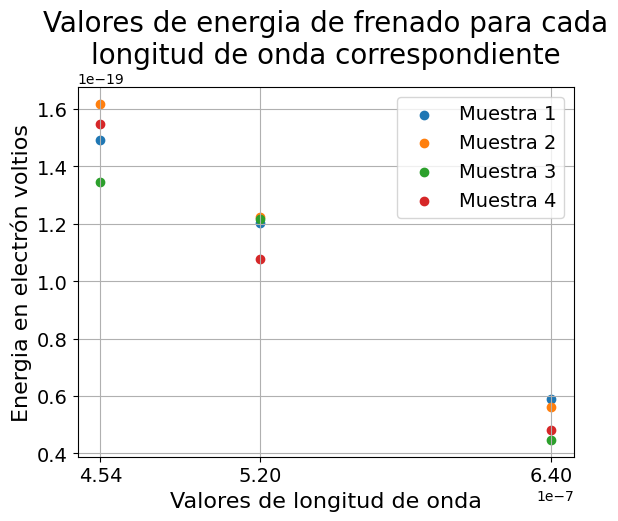

In [15]:
# Array de las longitudes de onda y los voltajes de frenado para varios intentos

data = np.array(
        [['lambda',640e-9, 520e-9, 454e-9],
        [1, 368, 752, 931 ],
        [2, 351, 765, 1010],
        [3, 279, 759, 840],
        [4, 301, 672, 966]])

# Gráfica para cada muestra de la magnitud del pico en electron voltios vs la longitud de onda
plt.title('Valores de energia de frenado para cada\nlongitud de onda correspondiente',
          fontsize = 20)
l = data[0, 1:].astype(float)

for i in range(1,5):
   
    y = data[i, 1:].astype(float)
    plt.scatter(l,y*1.602e-22, label = f'Muestra {i}')

plt.legend(fontsize = 14)
plt.xticks(l, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xlabel('Valores de longitud de onda', fontsize = 16)
plt.ylabel('Energia en electrón voltios', fontsize = 16)
plt.savefig('Articulo/images/Voltaje_de_frenado.jpg',    bbox_inches='tight',
    dpi=300)
plt.grid()

## Ajuste lineal de la ley de planck

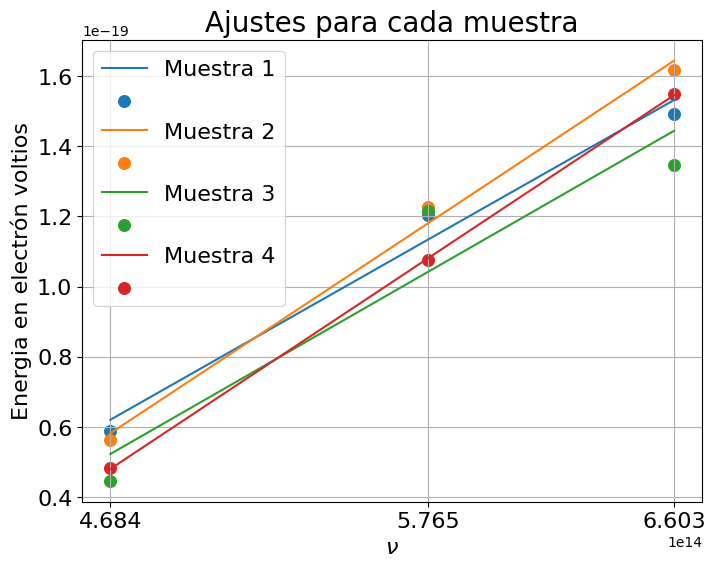

In [16]:
# Realizamos ajuste lineal de los datos para cada caso
a = np.zeros(4)
b = np.zeros(4)
cova = np.zeros(4)
covb = np.zeros(4)
r_2 = np.zeros(4)
nu = c/l
plt.figure(figsize = (8,6))
plt.title('Ajustes para cada muestra', fontsize = 20)
for i in range(4):
    y = data[i + 1 , 1:].astype(float)
    E = y*1.602e-22 #Energía en electron voltios
    
    par, cov = curve_fit(lineal,nu ,E )
    a[i] = par[0]
    b[i] = par[1]
    cova[i] = cov[0,0]
    covb[i] = cov[1,1]
    Eaj = lineal(nu, a[i], b[i])
    plt.plot(nu, Eaj,  label = f'Muestra {i +1}')
    plt.scatter(nu,E,marker= 'o',s = 70, label = ' ')
    r_2[i] = r2(Eaj, E)

plt.legend(fontsize = 16)
plt.xticks(nu, fontsize = 16)
plt.yticks(fontsize = 16)
plt.xlabel('$\\nu$', fontsize = 16)
plt.ylabel('Energia en electrón voltios', fontsize = 16)
plt.savefig('Articulo/images/Ajustes_para_cada_muestra.jpg',
            bbox_inches='tight',
            dpi=300
            )
plt.grid()

In [17]:
hexp = np.mean(a)
ep = error_porcentual(h, hexp)
ees =(1/4) * np.sqrt(np.sum(cova**2))
est = np.std(a)/np.sqrt(len(a))

print(f'el error porcentual de la constante de Plank por el anterior método es {ep} ')
print(f'el error estadistico es {ees}')
print(f'el error estandar es {est}')
print(f'los valores de rcuadrado corresponden a {r_2}')
print(hexp)

el error porcentual de la constante de Plank por el anterior método es 0.22185084926306084 
el error estadistico es 6.280365326964957e-69
el error estandar es 1.9214867535833884e-35
los valores de rcuadrado corresponden a [0.98207877 0.99452536 0.90300937 0.99996177]
5.156070743223511e-34


In [18]:
fexp = np.mean(b)

ees =(1/4) * np.sqrt(np.sum(covb**2))
est = np.std(b)/np.sqrt(len(b))

# print(f'el error porcentual de la constante de Plank por el anterior método es {ep} ')
print(f'el error estadistico es {ees}')
print(f'el error estandar es {est}')
# print(f'los valores de rcuadrado corresponden a {r_2}')
print(fexp)

el error estadistico es 2.0680110445791188e-39
el error estandar es 1.0411869745333578e-20
-1.8636585307763169e-19


# Parte 2

## Voltajes del pico de emisión correspondientes a cada led
Dados tres led rojo, azul y verde, conéctelos a una fuente DC con voltaje de 1.8 V para el rojo, 2.3 V para el verde y 2.8 V para el azul. Mida con el
espectrómetro su longitud de onda pico.

In [19]:
Picos = np.array([ 688.32e-9, 526.64e-9, 461.23e-9])
Voltaje = np.array([2, 2.4, 2.8 ])

Luego conecte cada led directamente a la fuente DC, con el voltaje de esta en 1.4 V. Aumente lentamente el voltaje hasta que el led empiece a emitir. Anote a que voltaje ocurre esto para cada led.
Grafique longitud de onda pico vs voltaje y ajuste a una recta.

Para este próposito realizamos el ajuste a la siguiente función.

$$
V = \frac{hc}{e}\frac{1}{\lambda} - \frac{\phi}{e}
$$

el valor de la constante de planck  calculada del ajsute corresponde a 
1.662658966080926e-33
la funcion trabajo del material corresponde a : 
2.4714061518048664e-19 mas o menos1.2629135029064131e-20
 el error porcentual de la constante de planck por medio de este procedimiento corresponde a un valor de 1.51
la incertidumbre encontrada por medio de la varianza corresponde a 1.2132036328662242e-41
El valor de r^2 corresponde a 0.9912615248392379


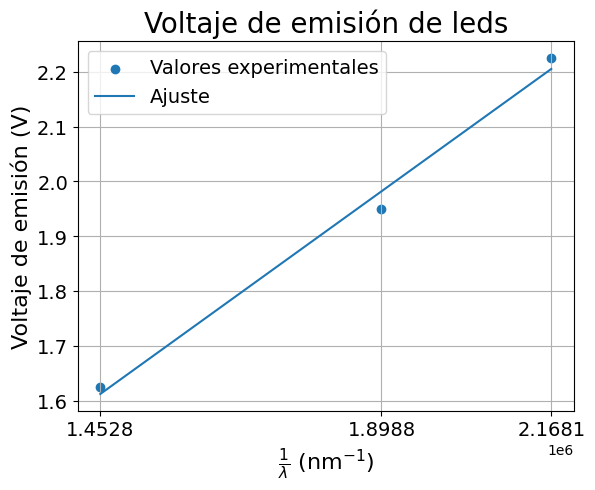

In [20]:
V_em = np.array([ 1.625, 1.950, 2.225]) #Valores de los voltjes de emision

#Ajuste lineal a la longitud de onda correspondiente
picos = 1/Picos
parametros, cov = curve_fit(lineal, picos, V_em) 
a = parametros[0]
b = parametros[1]
Vaj = lineal(picos, a, b)
#Gráficas
plt.title('Voltaje de emisión de leds', fontsize = 20)
plt.scatter(picos, V_em, label = 'Valores experimentales')
plt.plot(picos,Vaj , label = 'Ajuste')
plt.legend(fontsize = 14)
plt.xticks(picos, fontsize = 14)
plt.yticks(fontsize = 14)
plt.xlabel(r'$\frac{1}{\lambda}\;(\mathrm{nm}^{-1})$', fontsize=16)
plt.ylabel('Voltaje de emisión (V)', fontsize = 16)
plt.savefig('Articulo/images/Voltaje_de_emisión_leds.jpg',
            bbox_inches='tight',
            dpi=300)

plt.grid()


e =  6.022e-19
hexp = a *e/c
ep = error_porcentual(h, hexp)
inc = cov[0,0] * e/c

r_2 = r2(Vaj, V_em)
print( f'el valor de la constante de planck  calculada del ajsute corresponde a \n{hexp}')
print(f'la funcion trabajo del material corresponde a : \n{b* e} mas o menos{cov[1,1]* e}')
print(f' el error porcentual de la constante de planck por medio de este procedimiento corresponde a un valor de {ep:.2f}')
print(f'la incertidumbre encontrada por medio de la varianza corresponde a {inc}')
print( f'El valor de r^2 corresponde a {r_2}')